In [2]:
import pyarrow.parquet as pq
import polars as pl
pl.Config.set_tbl_cols(30)          # Show up to 20 columns
pl.Config.set_tbl_rows(50)   
pl.Config.set_tbl_width_chars(200)  # Make the table wider in the console
pl.Config.set_fmt_str_lengths(50)   # Don't cut off long strings like stoch_key

#results_path = r'C:\Users\Owner\airflow-trading\data_lake\Saved_results\Opt_Session_20260330_142341_01\master_metrics.parquet'
results_path = r'C:\Users\Owner\airflow-trading\data_lake\Saved_results\Opt_Session_20260401_191530_01\master_metrics.parquet'

# Open the file metadata
parquet_file = pq.ParquetFile(results_path)

df_master = pl.read_parquet(results_path)

# 1. Get Row Count
print(f"Total Rows: {parquet_file.metadata.num_rows}")

# 2. Get Schema
print("Schema:")
print(parquet_file.schema)

Total Rows: 684288
Schema:
required group field_id=-1 schema {
  optional int32 field_id=-1 regime_id;
  optional int64 field_id=-1 era_int;
  optional int32 field_id=-1 side (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 ma_int;
  optional boolean field_id=-1 ma_reversion;
  optional int32 field_id=-1 entry_lookback_units;
  optional int32 field_id=-1 exit_window_h;
  optional boolean field_id=-1 use_stochastic;
  optional binary field_id=-1 stoch_key (String);
  optional boolean field_id=-1 use_bbw;
  optional int32 field_id=-1 bbw_periods;
  optional float field_id=-1 bbw_std;
  optional int32 field_id=-1 bbw_thresholds;
  optional float field_id=-1 SL;
  optional float field_id=-1 TP;
  optional boolean field_id=-1 use_sl_decay;
  optional float field_id=-1 sl_decay_pct;
  optional int32 field_id=-1 sl_decay_interval;
  optional boolean field_id=-1 sl_decay_stop_at_pos;
  optional boolean field_id=-1 use_limit_entry;
  optional int32 field_id=-1 limit_window_h;
  op

In [2]:
import polars as pl


def print_era_safety_tables_final(df: pl.DataFrame, top_n: int = 10):
    lf = df.lazy()
    target_eras = [20230901, 20240301, 20240901, 20250301]

    for era in target_eras:
        print("\n" + "=" * 80)
        print(f"  ERA: {era} | RANKED BY LOWEST DRAWDOWN")
        print("=" * 80)

        era_table = (
            lf.filter(
                (pl.col("era_int") == era) &
                (pl.col("total_pos") > 50) &
                (pl.col("total_pos") < 1000)
            )
            .unique()
            .sort("max_drawdown", descending=False)
            .head(top_n)
            .collect()
        )

        if era_table.is_empty():
            print(f"No valid configurations found for Era {era}.")
        else:
            print(era_table)

            best_dd_value = era_table["max_drawdown"][0]
            print(f"\n>>> Era {era} Alpha: Best DD achieved was {best_dd_value:.2%}")
# Usage
print_era_safety_tables_final(df_master)


  ERA: 20230901 | RANKED BY LOWEST DRAWDOWN
shape: (10, 25)
┌─────────┬─────────┬──────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬───┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ regime_ ┆ era_int ┆ side ┆ ma_int ┆ ma_reve ┆ entry_l ┆ exit_wi ┆ use_sto ┆ stoch_k ┆ use_bbw ┆ … ┆ use_sl_ ┆ sl_deca ┆ sl_deca ┆ sl_deca ┆ use_lim ┆ limit_w ┆ total_p ┆ win_pos ┆ balance ┆ max_dr │
│ id      ┆ ---     ┆ ---  ┆ ---    ┆ rsion   ┆ ookback ┆ ndow_h  ┆ chastic ┆ ey      ┆ ---     ┆   ┆ decay   ┆ y_pct   ┆ y_inter ┆ y_stop_ ┆ it_entr ┆ indow_h ┆ os      ┆ ---     ┆ ---     ┆ awdown │
│ ---     ┆ i64     ┆ i8   ┆ i32    ┆ ---     ┆ _units  ┆ ---     ┆ ---     ┆ ---     ┆ bool    ┆   ┆ ---     ┆ ---     ┆ val     ┆ at_pos  ┆ y       ┆ ---     ┆ ---     ┆ i32     ┆ f32     ┆ ---    │
│ i32     ┆         ┆      ┆        ┆ bool    ┆ ---     ┆ i32     ┆ bool    ┆ str     ┆         ┆   ┆ bool    ┆ f32     ┆ ---     ┆ ---

In [3]:
# Map era -> volatility

amp_data = [
    {
        "era_int": 20220901,
        "window_start_time": "2022-09-01 00:00:00+00:00",
        "window_end_time": "2022-12-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26208,
        "window_min_close": 15593.58,
        "window_max_close": 22713.69,
        "regime_amp_index": 0.456605
    },
    {
        "era_int": 20221201,
        "window_start_time": "2022-12-01 00:00:00+00:00",
        "window_end_time": "2023-03-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 25920,
        "window_min_close": 16366.60,
        "window_max_close": 25235.36,
        "regime_amp_index": 0.541882
    },
    {
        "era_int": 20230301,
        "window_start_time": "2023-03-01 00:00:00+00:00",
        "window_end_time": "2023-06-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26496,
        "window_min_close": 19611.25,
        "window_max_close": 30963.13,
        "regime_amp_index": 0.578845
    },
    {
        "era_int": 20230601,
        "window_start_time": "2023-06-01 00:00:00+00:00",
        "window_end_time": "2023-09-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26496,
        "window_min_close": 24891.49,
        "window_max_close": 31710.95,
        "regime_amp_index": 0.273968
    },
    {
        "era_int": 20230901,
        "window_start_time": "2023-09-01 00:00:00+00:00",
        "window_end_time": "2023-12-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26208,
        "window_min_close": 25003.56,
        "window_max_close": 38383.09,
        "regime_amp_index": 0.535105
    },
    {
        "era_int": 20231201,
        "window_start_time": "2023-12-01 00:00:00+00:00",
        "window_end_time": "2024-03-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26208,
        "window_min_close": 37627.91,
        "window_max_close": 63690.12,
        "regime_amp_index": 0.692630
    },
    {
        "era_int": 20240301,
        "window_start_time": "2024-03-01 00:00:00+00:00",
        "window_end_time": "2024-06-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26496,
        "window_min_close": 56773.99,
        "window_max_close": 73628.42,
        "regime_amp_index": 0.296869
    },
    {
        "era_int": 20240601,
        "window_start_time": "2024-06-01 00:00:00+00:00",
        "window_end_time": "2024-09-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26496,
        "window_min_close": 49338.49,
        "window_max_close": 71956.73,
        "regime_amp_index": 0.458430
    },
    {
        "era_int": 20240901,
        "window_start_time": "2024-09-01 00:00:00+00:00",
        "window_end_time": "2024-12-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26208,
        "window_min_close": 52738.00,
        "window_max_close": 99521.87,
        "regime_amp_index": 0.887100
    },
    {
        "era_int": 20241201,
        "window_start_time": "2024-12-01 00:00:00+00:00",
        "window_end_time": "2025-03-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 25920,
        "window_min_close": 78487.01,
        "window_max_close": 108984.96,
        "regime_amp_index": 0.388573
    },
    {
        "era_int": 20250301,
        "window_start_time": "2025-03-01 00:00:00+00:00",
        "window_end_time": "2025-06-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26496,
        "window_min_close": 74610.00,
        "window_max_close": 111924.08,
        "regime_amp_index": 0.500122
    },
    {
        "era_int": 20250601,
        "window_start_time": "2025-06-01 00:00:00+00:00",
        "window_end_time": "2025-09-01 00:00:00+00:00",
        "timeframe_months": 3,
        "window_rows": 26496,
        "window_min_close": 98392.91,
        "window_max_close": 124243.32,
        "regime_amp_index": 0.262726
    },
    {
        "era_int": 20250901,
        "window_start_time": "2025-09-01 00:00:00+00:00",
        "window_end_time": "2025-09-15 23:59:59+00:00",
        "timeframe_months": 3,
        "window_rows": 4320,
        "window_min_close": 107303.99,
        "window_max_close": 116745.67,
        "regime_amp_index": 0.087990
    }
]
import polars as pl

# 1. Convert your list of dictionaries into a Polars DataFrame
# We only select 'era_int' and 'regime_amp_index' as those are the keys for correlation
amp_df = (
    pl.DataFrame(amp_data)
    .select([
        pl.col("era_int"),
        pl.col("regime_amp_index").alias("regime_amp")  # Rename to match your analysis script
    ])
    .with_columns(pl.col("era_int").cast(pl.Int64)) # Ensure data types match for the join
)

# 2. Link the Volatility data to your Master Backtest data
# This is the 'bridge' that allows you to calculate correlation
df_analysis = (
    df_master
    .with_columns(pl.col("era_int").cast(pl.Int64)) # Ensure join key types are identical
    .join(amp_df, on="era_int", how="left")        # Map volatility to every single trade result
    .filter(pl.col("total_pos") >= 30)             # Apply trade floor for significance
    .with_columns([
        # Volatility-Adjusted Alpha Calculation
        ((((pl.col("balance") - 100) / 100) / (pl.col("total_pos") + 1e-9)) / 
         (pl.col("max_drawdown").clip(0.001))).alias("alpha_per_trade"),
        
        # Total Trade Space (TP + SL)
        (pl.col("TP") + pl.col("SL")).alias("total_spread")
    ])
)

# 3. Aggregate to find the "Best" parameters for every Volatility level
regime_winners = (
    df_analysis
    .group_by(["regime_amp", "TP", "SL", "total_spread"])
    .agg(pl.col("alpha_per_trade").median().alias("median_alpha"))
    .sort(["regime_amp", "median_alpha"], descending=[False, True])
    .group_by("regime_amp")
    .head(1)
    .sort("regime_amp")
)

# 4. Final Spearman Rho Check
correlations = regime_winners.select([
    pl.corr("regime_amp", "TP", method="spearman").alias("rho_vol_vs_TP"),
    pl.corr("regime_amp", "SL", method="spearman").alias("rho_vol_vs_SL"),
    pl.corr("regime_amp", "total_spread", method="spearman").alias("rho_vol_vs_TotalSpread")
])

print("--- IDEAL PARAMETERS PER VOLATILITY REGIME ---")
print(regime_winners.select(["regime_amp", "TP", "SL", "total_spread", "median_alpha"]))

print("\n--- GLOBAL CORRELATION RESULTS ---")
print(correlations)

--- IDEAL PARAMETERS PER VOLATILITY REGIME ---
shape: (12, 5)
┌────────────┬─────┬─────┬──────────────┬──────────────┐
│ regime_amp ┆ TP  ┆ SL  ┆ total_spread ┆ median_alpha │
│ ---        ┆ --- ┆ --- ┆ ---          ┆ ---          │
│ f64        ┆ f32 ┆ f32 ┆ f32          ┆ f32          │
╞════════════╪═════╪═════╪══════════════╪══════════════╡
│ 0.262726   ┆ 2.5 ┆ 0.4 ┆ 2.9          ┆ -0.000614    │
│ 0.273968   ┆ 3.0 ┆ 0.6 ┆ 3.6          ┆ -0.000602    │
│ 0.296869   ┆ 2.0 ┆ 0.2 ┆ 2.2          ┆ 0.015431     │
│ 0.388573   ┆ 2.0 ┆ 0.6 ┆ 2.6          ┆ 0.02034      │
│ 0.456605   ┆ 2.5 ┆ 0.2 ┆ 2.7          ┆ 0.027969     │
│ 0.45843    ┆ 3.0 ┆ 0.2 ┆ 3.2          ┆ 0.051084     │
│ 0.500122   ┆ 2.5 ┆ 0.6 ┆ 3.1          ┆ 0.028679     │
│ 0.535105   ┆ 2.0 ┆ 0.2 ┆ 2.2          ┆ 0.014153     │
│ 0.541882   ┆ 2.0 ┆ 0.4 ┆ 2.4          ┆ 0.005441     │
│ 0.578845   ┆ 3.0 ┆ 0.6 ┆ 3.6          ┆ 0.000005     │
│ 0.69263    ┆ 2.5 ┆ 0.4 ┆ 2.9          ┆ 0.003471     │
│ 0.8871     ┆ 2.5 ┆ 0.6 ┆

In [52]:
import polars as pl

# Group by era and stochastic key, calculate performance metrics
stoch_performance = (
    df_master
    .group_by(["era_int", "stoch_key"])
    .agg([
        pl.col("balance").median().alias("median_balance"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        (pl.col("win_pos").mean() / (pl.col("total_pos").mean() + 1e-9)).alias("avg_win_rate"),
        pl.col("total_pos").mean().alias("avg_total_pos"),
    ])
    .with_columns([
        (pl.col("median_balance") / (pl.col("avg_dd") + 1e-9)).alias("efficiency"),
        (
            (pl.col("median_balance") / (pl.col("avg_dd") + 1e-9))
            / (pl.col("avg_total_pos") + 1e-9)
        ).alias("efficiency_per_trade"),
    ])
    .sort(["era_int", "efficiency"], descending=[False, True])
)

print("--- STOCH_KEY PERFORMANCE BY ERA (EFFICIENCY) ---")
print(stoch_performance)

# Prepare df_eff with efficiency columns for global ranking
df_eff = df_master.with_columns([
    (pl.col("balance") / (pl.col("max_drawdown") + 1e-9)).alias("efficiency"),
    ((pl.col("balance") / (pl.col("max_drawdown") + 1e-9)) / (pl.col("total_pos") + 1e-9)).alias("efficiency_per_trade")
])

# Top 20% by efficiency
total_rows = df_eff.height
cutoff = int(total_rows * 0.1)

top_eff = (
    df_eff
    .with_columns(
        pl.col("efficiency").rank(method="dense", descending=True).alias("rank_eff")
    )
    .filter(pl.col("rank_eff") <= cutoff)
    .group_by("stoch_key")
    .agg(
        pl.len().alias("top_eff_count")
    )
    .with_columns(
        (pl.col("top_eff_count") / pl.col("top_eff_count").sum()).alias("top_eff_share")
    )
    .sort("top_eff_count", descending=True)
)

print("--- GLOBAL TOP 10% BY EFFICIENCY — STOCH_KEY DOMINANCE ---")
print(top_eff)

# Top 20% by efficiency per trade
top_eff_pt = (
    df_eff
    .with_columns(
        pl.col("efficiency_per_trade").rank(method="dense", descending=True).alias("rank_eff_pt")
    )
    .filter(pl.col("rank_eff_pt") <= cutoff)
    .group_by("stoch_key")
    .agg(
        pl.len().alias("top_eff_pt_count")
    )
    .with_columns(
        (pl.col("top_eff_pt_count") / pl.col("top_eff_pt_count").sum()).alias("top_eff_pt_share")
    )
    .sort("top_eff_pt_count", descending=True)
)

print("--- GLOBAL TOP 10% BY EFFICIENCY PER TRADE — STOCH_KEY DOMINANCE ---")
print(top_eff_pt)

--- STOCH_KEY PERFORMANCE BY ERA (EFFICIENCY) ---
shape: (12, 8)
┌──────────┬──────────────────┬────────────────┬──────────┬──────────────┬───────────────┬─────────────┬──────────────────────┐
│ era_int  ┆ stoch_key        ┆ median_balance ┆ avg_dd   ┆ avg_win_rate ┆ avg_total_pos ┆ efficiency  ┆ efficiency_per_trade │
│ ---      ┆ ---              ┆ ---            ┆ ---      ┆ ---          ┆ ---           ┆ ---         ┆ ---                  │
│ i64      ┆ str              ┆ f32            ┆ f32      ┆ f64          ┆ f64           ┆ f32         ┆ f64                  │
╞══════════╪══════════════════╪════════════════╪══════════╪══════════════╪═══════════════╪═════════════╪══════════════════════╡
│ 20230901 ┆ k3_d6_s6_l30_u70 ┆ 99.707245      ┆ 0.064946 ┆ 0.209419     ┆ 146.458333    ┆ 1535.2229   ┆ 10.482319            │
│ 20230901 ┆ k4_d6_s6_l30_u70 ┆ 99.666367      ┆ 0.084216 ┆ 0.211578     ┆ 246.333333    ┆ 1183.467529 ┆ 4.804334             │
│ 20230901 ┆ k6_d6_s6_l30_u70 ┆ 96.3955

In [8]:
import polars as pl

def feature_performance(df_master: pl.DataFrame, feature_col: str, top_pct: float = 0.1, trade_floor: int = 50):
    """
    Calculate per-era performance and top elite per era for a given feature.
    Top elite is selected by Alpha and Efficiency, with output focused on 
    global dominance and median quality metrics.
    """
    
    # --- 0. Apply Significance Filter ---
    df_filtered = df_master.filter(pl.col("total_pos") >= trade_floor)
    if df_filtered.is_empty():
        print(f"No strategies found with total_pos >= {trade_floor}")
        return None, None

    # --- 1. Performance by era ---
    perf_by_era = (
        df_filtered
        .group_by(["era_int", feature_col])
        .agg([
            pl.col("balance").median().alias("median_balance"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            (pl.col("win_pos").mean() / (pl.col("total_pos").mean() + 1e-9)).alias("avg_win_rate"),
            pl.col("total_pos").mean().alias("avg_total_pos"),
        ])
        .with_columns([
            ((pl.col("median_balance") / (pl.col("avg_dd") + 1e-9)) / (pl.col("avg_total_pos") + 1e-9)).alias("efficiency_per_trade"),
            # True Alpha per Trade % adjusted for drawdown
            (((pl.col("median_balance") - 100) / 100) / (pl.col("avg_total_pos") + 1e-9) / (pl.col("avg_dd") + 1e-9)).alias("alpha_per_trade")
        ])
        # Sorting for internal era view
        .sort(["era_int", "alpha_per_trade"], descending=[False, True])
    )
    
    # --- 2. Prepare efficiency columns for top elite ---
    df_eff_era = df_filtered.with_columns([
        ((pl.col("balance") / (pl.col("max_drawdown") + 1e-9)) / (pl.col("total_pos") + 1e-9)).alias("efficiency_per_trade"),
        (((pl.col("balance") - 100) / 100) / (pl.col("total_pos") + 1e-9) / (pl.col("max_drawdown") + 1e-9)).alias("alpha_per_trade")
    ])
    
    # --- 3. Top elite per era selection ---
    eras = df_eff_era["era_int"].unique().to_list()
    top_elite_rows = []

    for era in eras:
        era_df = df_eff_era.filter(pl.col("era_int") == era)
        cutoff = max(1, int(len(era_df) * top_pct))
        top_rows = era_df.sort(
            ["alpha_per_trade", "efficiency_per_trade"], 
            descending=[True, True]
        ).head(cutoff)
        top_elite_rows.append(top_rows)

    top_elite_per_era = pl.concat(top_elite_rows)
    total_pool_size = top_elite_per_era.height

    # --- 4. Global Stats (The "Floor" for every MA) ---
    global_stats = (
        df_eff_era
        .group_by(feature_col)
        .agg([
            pl.col("alpha_per_trade").median().alias("global_median_alpha"),
            pl.col("efficiency_per_trade").median().alias("global_median_eff")
        ])
    )

    # --- 5. Aggregate Top Elite and Join with Global ---
    top_elite_consistency = (
        top_elite_per_era
        .group_by(feature_col)
        .agg([
            (pl.len().cast(pl.Float64) / total_pool_size).alias("dominance_score"),
            pl.col("era_int").n_unique().alias("_eras_found"),
            pl.col("alpha_per_trade").median().alias("elite_median_alpha"),
        ])
        .with_columns([
            (pl.col("_eras_found") / len(eras)).alias("era_consistency_score")
        ])
        # Join with the Global Stats
        .join(global_stats, on=feature_col, how="left")
        .with_columns([
            # The "Elite Lift" - How much better is the top 10% than the average?
            (pl.col("elite_median_alpha") - pl.col("global_median_alpha")).alias("alpha_lift")
        ])
        .drop("_eras_found")
        .sort(["era_consistency_score", "elite_median_alpha"], descending=True)
    )

    # Printing outputs
    print(f"\n--- {feature_col.upper()} PERFORMANCE BY ERA (FLOOR: {trade_floor}) ---")
    print(perf_by_era.select([
        "era_int", feature_col, "median_balance", "avg_dd", 
        "avg_win_rate", "avg_total_pos", "efficiency_per_trade", "alpha_per_trade"
    ]))

    print(f"\n--- TOP ELITE PER ERA DOMINANCE (top {int(top_pct*100)}% per era) ---")
    print(top_elite_consistency)

    return perf_by_era, top_elite_consistency

# Run tests
#results_stoch = feature_performance(df_master, "stoch_key")
results_ma = feature_performance(df_master, "ma_int")
results_lookback = feature_performance(df_master, "entry_lookback_units")
results_exit = feature_performance(df_master, "exit_window_h")
results_tp = feature_performance(df_master, "TP")
results_sl = feature_performance(df_master, "SL")
results_limit = feature_performance(df_master, "limit_window_h")
results_limit = feature_performance(df_master, "sl_decay_pct")
results_interval = feature_performance(df_master, "trade_window_interval")


--- MA_INT PERFORMANCE BY ERA (FLOOR: 50) ---
shape: (192, 8)
┌──────────┬────────┬────────────────┬──────────┬──────────────┬───────────────┬──────────────────────┬─────────────────┐
│ era_int  ┆ ma_int ┆ median_balance ┆ avg_dd   ┆ avg_win_rate ┆ avg_total_pos ┆ efficiency_per_trade ┆ alpha_per_trade │
│ ---      ┆ ---    ┆ ---            ┆ ---      ┆ ---          ┆ ---           ┆ ---                  ┆ ---             │
│ i64      ┆ i32    ┆ f32            ┆ f32      ┆ f64          ┆ f64           ┆ f64                  ┆ f64             │
╞══════════╪════════╪════════════════╪══════════╪══════════════╪═══════════════╪══════════════════════╪═════════════════╡
│ 20220901 ┆ 13     ┆ 104.831001     ┆ 0.022833 ┆ 0.195841     ┆ 60.960438     ┆ 75.316097            ┆ 0.034708        │
│ 20220901 ┆ 12     ┆ 105.682343     ┆ 0.024364 ┆ 0.192941     ┆ 70.711279     ┆ 61.342138            ┆ 0.032983        │
│ 20220901 ┆ 10     ┆ 105.644745     ┆ 0.026005 ┆ 0.193579     ┆ 66.490741     ┆ 61

In [7]:
import polars as pl

# -----------------------------
# Parameters
# -----------------------------
trade_floor = 50
elite_pct = 0.10

# -----------------------------
# 1. Base filter + core metrics
# -----------------------------
df = (
    df_master
    .filter(
        (pl.col("total_pos") >= trade_floor) &
        (pl.col("use_sl_decay") == True)
    )
    .with_columns([
        (((pl.col("balance") - 100) / 100)
         / (pl.col("total_pos") + 1e-9)
         / (pl.col("max_drawdown") + 1e-9)
        ).alias("alpha_per_trade")
    ])
)

# -----------------------------
# 2. GLOBAL interaction surface
# -----------------------------
interaction_global = (
    df
    .group_by(["exit_window_h", "sl_decay_pct"])
    .agg([
        pl.col("alpha_per_trade").median().alias("median_alpha"),
        pl.len().alias("n_models"),
    ])
    .sort(["exit_window_h", "sl_decay_pct"])
)

print("\n--- GLOBAL EXIT × SL DECAY ALPHA SURFACE ---")
print(interaction_global)

# -----------------------------
# 3. ELITE-ONLY interaction
# -----------------------------
cutoff = df.select(pl.col("alpha_per_trade").quantile(1 - elite_pct)).item()

interaction_elite = (
    df
    .filter(pl.col("alpha_per_trade") >= cutoff)
    .group_by(["exit_window_h", "sl_decay_pct"])
    .agg([
        pl.col("alpha_per_trade").median().alias("elite_median_alpha"),
        pl.len().alias("n_elite"),
    ])
    .sort(["exit_window_h", "sl_decay_pct"])
)

print("\n--- ELITE-ONLY EXIT × SL DECAY ALPHA SURFACE ---")
print(interaction_elite)

# -----------------------------
# 4. Correlation diagnostics
# -----------------------------
corrs = (
    df
    .select([
        pl.corr("exit_window_h", "alpha_per_trade").alias("corr_exit_alpha"),
        pl.corr("sl_decay_pct", "alpha_per_trade").alias("corr_decay_alpha"),
    ])
)

print("\n--- GLOBAL CORRELATIONS ---")
print(corrs)


--- GLOBAL EXIT × SL DECAY ALPHA SURFACE ---
shape: (33, 4)
┌───────────────┬──────────────┬──────────────┬──────────┐
│ exit_window_h ┆ sl_decay_pct ┆ median_alpha ┆ n_models │
│ ---           ┆ ---          ┆ ---          ┆ ---      │
│ i32           ┆ f32          ┆ f32          ┆ u32      │
╞═══════════════╪══════════════╪══════════════╪══════════╡
│ 2             ┆ 0.2          ┆ 0.002088     ┆ 8360     │
│ 2             ┆ 0.3          ┆ 0.002467     ┆ 8363     │
│ 2             ┆ 0.5          ┆ 0.00322      ┆ 8381     │
│ 4             ┆ 0.2          ┆ 0.004618     ┆ 8171     │
│ 4             ┆ 0.3          ┆ 0.005958     ┆ 8224     │
│ 4             ┆ 0.5          ┆ 0.007974     ┆ 8295     │
│ 6             ┆ 0.2          ┆ 0.005263     ┆ 8018     │
│ 6             ┆ 0.3          ┆ 0.006492     ┆ 8104     │
│ 6             ┆ 0.5          ┆ 0.008587     ┆ 8208     │
│ 8             ┆ 0.2          ┆ 0.004332     ┆ 7904     │
│ 8             ┆ 0.3          ┆ 0.005126     ┆ 7999  

In [24]:
import polars as pl

def recursive_elite_selection(
    df_master: pl.DataFrame,
    feature_cols: list,
    top_pct: float = 0.1,
    trade_floor: int = 50
):
    """
    Recursive elite selection aligned with feature_performance logic:
    - Selection is PER ERA
    - Ranking metric: efficiency_per_trade
    - Feature value is chosen by:
        1) Era consistency
        2) Total top appearances (dominance)
        3) Efficiency per trade (tie-breaker only)
    """

    df_filtered = df_master.filter(pl.col("total_pos") >= trade_floor)
    elite_summary = []

    for feature in feature_cols:
        # --- 1. Compute efficiency_per_trade ---
        df_eff = df_filtered.with_columns([
            ((pl.col("balance") / (pl.col("max_drawdown") + 1e-9)) /
             (pl.col("total_pos") + 1e-9)).alias("efficiency_per_trade")
        ])

        eras = df_eff["era_int"].unique().to_list()
        top_rows_all_eras = []

        # --- 2. Select top X% PER ERA ---
        for era in eras:
            era_df = df_eff.filter(pl.col("era_int") == era)
            if era_df.is_empty():
                continue

            cutoff = max(1, int(era_df.height * top_pct))
            top_rows = (
                era_df
                .sort("efficiency_per_trade", descending=True)
                .head(cutoff)
            )
            top_rows_all_eras.append(top_rows)

        if not top_rows_all_eras:
            break

        top_elite = pl.concat(top_rows_all_eras)

        # --- 3. Era dominance scoring ---
        feature_score = (
            top_elite
            .group_by(feature)
            .agg([
                pl.col("era_int").n_unique().alias("eras_present"),
                pl.len().alias("total_top_instances"),
                pl.col("efficiency_per_trade").median().alias("median_eff_per_trade")
            ])
            .with_columns([
                (pl.col("eras_present") / len(eras)).alias("era_consistency_score")
            ])
            .sort(
                [
                    "era_consistency_score",   # must be consistent
                    "total_top_instances",     # dominance matters most
                    "median_eff_per_trade"     # quality as tie-breaker
                ],
                descending=[True, True, True]
            )
        )

        # --- 4. Pick dominant feature value ---
        top_value = feature_score[0, feature]

        elite_summary.append({
            "feature": feature,
            "top_value": top_value,
            "era_consistency": feature_score[0, "era_consistency_score"],
            "eras_present": feature_score[0, "eras_present"],
            "total_top_instances": feature_score[0, "total_top_instances"],
            "median_eff_per_trade": feature_score[0, "median_eff_per_trade"]
        })

        # --- 5. Filter for next recursion ---
        df_filtered = df_filtered.filter(pl.col(feature) == top_value)

        if df_filtered.height <= 1:
            break

    print("--- ELITE FEATURE COMBINATION SUMMARY (ERA DOMINANCE) ---")
    for e in elite_summary:
        print(e)

    print(f"\nFinal filtered dataset: {df_filtered.height} rows")
    return df_filtered, elite_summary

selected_features = [
    "stoch_key", "ma_int", "entry_lookback_units", 
    "exit_window_h", "TP", "SL", "sl_decay_pct", "use_sl_decay"
]

selected_features = [
    "trade_window_interval", "stoch_key", "ma_int", "entry_lookback_units", 
    "exit_window_h", "TP", "SL", "sl_decay_pct", "use_sl_decay"
]

df_elite, summary = recursive_elite_selection(df_master, selected_features)

--- ELITE FEATURE COMBINATION SUMMARY (ERA DOMINANCE) ---
{'feature': 'trade_window_interval', 'top_value': 12, 'era_consistency': 1.0, 'eras_present': 12, 'total_top_instances': 15736, 'median_eff_per_trade': 115.45074462890625}
{'feature': 'stoch_key', 'top_value': 'k6_d6_s6_l30_u70', 'era_consistency': 1.0, 'eras_present': 12, 'total_top_instances': 4704, 'median_eff_per_trade': 128.41375732421875}
{'feature': 'ma_int', 'top_value': 3, 'era_consistency': 1.0, 'eras_present': 12, 'total_top_instances': 1808, 'median_eff_per_trade': 129.90927124023438}
{'feature': 'entry_lookback_units', 'top_value': 2, 'era_consistency': 1.0, 'eras_present': 12, 'total_top_instances': 479, 'median_eff_per_trade': 148.0550537109375}
{'feature': 'exit_window_h', 'top_value': 1, 'era_consistency': 0.9166666666666666, 'eras_present': 11, 'total_top_instances': 389, 'median_eff_per_trade': 142.051513671875}
{'feature': 'TP', 'top_value': 2.200000047683716, 'era_consistency': 1.0, 'eras_present': 12, 'tota

In [6]:
import polars as pl

# 1. Define your unique parameter columns (The 'DNA' of your strategy)
param_cols = [
    "stoch_key", "ma_int", "entry_lookback_units", 
    "exit_window_h", "TP", "SL", "limit_window_h", "trade_window_interval"
]

# 2. Calculate Per-Era Alpha first
df_with_alpha = df_master.with_columns([
    ((((pl.col("balance") - 100) / 100) / (pl.col("total_pos") + 1e-9)) / 
     (pl.col("max_drawdown").clip(0.001))).alias("era_alpha")
])

# 3. Calculate Consistency Metrics per Parameter Set
# We want to know: In how many unique eras was this strategy positive?
total_eras = df_master["era_int"].n_unique()

consistency_map = (
    df_with_alpha
    .group_by(param_cols)
    .agg([
        pl.col("era_alpha").median().alias("median_global_alpha"),
        pl.col("balance").mean().alias("avg_balance"),
        pl.col("total_pos").sum().alias("total_trades_all_eras"),
        # Count eras where Alpha > 0
        (pl.col("era_alpha") > 0).sum().alias("positive_era_count"),
        pl.col("era_int").n_unique().alias("total_eras_tested")
    ])
    .with_columns([
        (pl.col("positive_era_count") / pl.col("total_eras_tested")).alias("consistency_rate")
    ])
)

# 4. Filter for 50% Consistency and Min Trades
all_weather_leaderboard = (
    consistency_map
    .filter(
        (pl.col("consistency_rate") >= 0.5) & 
        (pl.col("total_trades_all_eras") >= 50)
    )
    .sort("median_global_alpha", descending=True)
)

# 5. Display results
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(1000)

print(f"--- ALL-WEATHER STRATEGIES (Profitable in {int(0.5*total_eras)}+ out of {total_eras} Eras) ---")
print(all_weather_leaderboard.head(20))

--- ALL-WEATHER STRATEGIES (Profitable in 6+ out of 12 Eras) ---
shape: (20, 14)
┌──────────────────┬────────┬──────────────────────┬───────────────┬─────┬─────┬────────────────┬───────────────────────┬─────────────────────┬─────────────┬───────────────────────┬────────────────────┬───────────────────┬──────────────────┐
│ stoch_key        ┆ ma_int ┆ entry_lookback_units ┆ exit_window_h ┆ TP  ┆ SL  ┆ limit_window_h ┆ trade_window_interval ┆ median_global_alpha ┆ avg_balance ┆ total_trades_all_eras ┆ positive_era_count ┆ total_eras_tested ┆ consistency_rate │
│ ---              ┆ ---    ┆ ---                  ┆ ---           ┆ --- ┆ --- ┆ ---            ┆ ---                   ┆ ---                 ┆ ---         ┆ ---                   ┆ ---                ┆ ---               ┆ ---              │
│ str              ┆ i32    ┆ i32                  ┆ i32           ┆ f32 ┆ f32 ┆ i32            ┆ i32                   ┆ f32                 ┆ f32         ┆ i32                   ┆ u32        

In [9]:
# --- CELL: BEST SL x TP FOR SELECTED CONFIG --- 
import polars as pl

# --- CONFIG ---
TARGET_STOCH = "k6_d6_s6_l30_u70"
TARGET_MA = [5, 7]          # ma_int values
MIN_TRADES_PER_CONFIG = 30   # ensure some statistical relevance
EPS = 1e-9

# --- FILTER DATA ---
df_sub = df_master.filter(
    (pl.col("stoch_key") == TARGET_STOCH) &
    (pl.col("ma_int").is_in(TARGET_MA))
)

# --- GROUP BY SL / TP ---
# assuming df_master has 'sl' and 'tp' columns
sl_tp_stats = (
    df_sub.groupby(["SL", "TP"])
          .agg([
              pl.mean("balance").alias("avg_balance"),
              pl.mean("max_drawdown").alias("avg_dd"),
              pl.sum("total_pos").alias("total_trades"),
              pl.sum("win_pos").alias("total_wins")
          ])
          .with_columns([
              ((pl.col("avg_balance") - 100) / (pl.col("avg_dd") + EPS)).alias("efficiency"),
              ((pl.col("avg_balance") - 100) / (pl.col("total_trades") + EPS)).alias("eff_per_trade"),
              (pl.col("total_wins") / (pl.col("total_trades") + EPS)).alias("win_rate")
          ])
          .filter(pl.col("total_trades") >= MIN_TRADES_PER_CONFIG)
          .sort("eff_per_trade", descending=True)
)

print("\n--- BEST SL x TP FOR STOCHASTIC k6_d6_s6_l30_u70 AND MA_INT 5+7 ---")
print(sl_tp_stats.to_pandas().to_string(index=False))


--- BEST SL x TP FOR STOCHASTIC k6_d6_s6_l30_u70 AND MA_INT 5+7 ---
 SL  TP  avg_balance   avg_dd  total_trades  total_wins  efficiency  eff_per_trade  win_rate
0.1 1.6   111.909233 0.073991         32212        3016  160.955740       0.000370  0.093630
0.1 1.4   110.498871 0.069610         32212        3316  150.824773       0.000326  0.102943
0.1 1.8   109.943359 0.079424         32212        2572  125.193747       0.000309  0.079846
0.1 2.2   109.357880 0.089012         32212        2044  105.130465       0.000291  0.063455
0.1 2.0   109.335602 0.085381         32212        2246  109.339904       0.000290  0.069726
0.2 1.4   108.454849 0.054094         32212        5900  156.298351       0.000262  0.183162
0.1 2.4   108.083496 0.094012         32212        1810   85.983922       0.000251  0.056190
0.1 1.2   108.068375 0.069490         32212        3528  116.108663       0.000250  0.109524
0.2 1.6   108.021797 0.059041         32212        5170  135.867765       0.000249  0.160499
0

In [13]:
# --- CELL: ERA-BY-ERA CHECK FOR SELECTED STRATEGY ---
import polars as pl

# --- FILTER DATA FOR THE STRATEGY ---
selected_ma_ints = [5, 7]
selected_stoch = "k6_d6_s6_l30_u70"
selected_SL = 0.1
selected_TP = 2.0

df_strategy = df_master.filter(
    (pl.col("stoch_key") == selected_stoch) &
    (pl.col("ma_int").is_in(selected_ma_ints)) &
    (pl.col("SL") == selected_SL) &
    (pl.col("TP") == selected_TP)
)

# --- GROUP BY ERA AND CALCULATE STATS ---
era_stats = (
    df_strategy.groupby("era_int")
               .agg([
                   pl.col("balance").mean().alias("avg_balance"),
                   pl.col("max_drawdown").mean().alias("avg_dd"),
                   pl.col("total_pos").sum().alias("total_trades"),
                   pl.col("win_pos").sum().alias("total_wins"),
                   ((pl.col("balance").mean() - 100) / (pl.col("max_drawdown").mean() + 1e-9)).alias("efficiency"),
                   ((pl.col("balance").mean() - 100) / ((pl.col("total_pos").sum() / df_strategy["era_int"].n_unique()) + 1e-9) / (pl.col("max_drawdown").mean() + 1e-9)).alias("eff_per_trade"),
                   (pl.col("win_pos").sum() / pl.col("total_pos").sum()).alias("win_rate")
               ])
               .sort("era_int")
)

print("\n--- ERA-BY-ERA PERFORMANCE ---")
print(era_stats.to_pandas())


--- ERA-BY-ERA PERFORMANCE ---
    era_int  avg_balance    avg_dd  total_trades  total_wins  efficiency  \
0  20230901    90.837646  0.097478          6736         100  -93.994358   
1  20240301   112.922768  0.058086          7408         632  222.477486   
2  20240901   121.227257  0.064302          7400         758  330.117123   
3  20250301   112.354874  0.121660         10668         756  101.552221   

   eff_per_trade  win_rate  
0      -0.055816  0.014846  
1       0.120128  0.085313  
2       0.178442  0.102432  
3       0.038077  0.070866  


In [16]:
# --- CELL: LOOKBACK vs WIN RATE CORRELATION (FIXED) ---
import polars as pl

MIN_TRADES = 50

# --- AGGREGATE FIRST ---
df_lb = (
    df_master
    .filter(pl.col("total_pos") >= MIN_TRADES)
    .groupby(["era_int", "entry_lookback_units"])
    .agg([
        pl.col("total_pos").sum().alias("total_trades"),
        pl.col("win_pos").sum().alias("total_wins")
    ])
    .with_columns(
        (pl.col("total_wins") / pl.col("total_trades")).alias("win_rate"),
        pl.col("entry_lookback_units").cast(pl.Float64).alias("lookback_f")
    )
    .sort(["era_int", "entry_lookback_units"])
)

print("\n--- WIN RATE BY ERA & LOOKBACK UNIT ---")
print(df_lb.to_pandas().to_string(index=False))

# --- CORRELATION PER ERA (SAFE CAST) ---
corr_stats = (
    df_lb
    .groupby("era_int")
    .agg([
        pl.corr("lookback_f", "win_rate").alias("corr_lookback_winrate"),
        pl.count().alias("num_lookbacks")
    ])
    .sort("era_int")
)

print("\n--- CORRELATION: LOOKBACK UNIT vs WIN RATE (PER ERA) ---")
print(corr_stats.to_pandas().to_string(index=False))


--- WIN RATE BY ERA & LOOKBACK UNIT ---
 era_int  entry_lookback_units  total_trades  total_wins  win_rate  lookback_f
20230901                     6       2651800      338239  0.127551         6.0
20230901                     8        744975       97892  0.131403         8.0
20230901                    12         21700        4310  0.198618        12.0
20240301                     6       2797760      384387  0.137391         6.0
20240301                     8        956795      147136  0.153780         8.0
20240901                     6       3248830      485680  0.149494         6.0
20240901                     8        956635      142895  0.149373         8.0
20240901                    12         39900        3712  0.093033        12.0
20250301                     6       4900665      659912  0.134658         6.0
20250301                     8       2846790      418616  0.147048         8.0
20250301                    12        211185       33108  0.156772        12.0

--- CORREL

In [5]:
# --- CELL: BEST TP PER ERA (FIXED STOCH + MA_INT 5/7) ---
import polars as pl

EPS = 1e-9

# Filter once (important for correctness & speed)
df_base = df_master.filter(
    (pl.col("stoch_key") == "k6_d6_s6_l30_u70") &
    (pl.col("ma_int").is_in([5, 7])) &
    (pl.col("total_pos") > 0)
)

# Aggregate by era + TP
df_tp_era = (
    df_base
    .group_by(["era_int", "TP"])
    .agg([
        pl.col("balance").mean().alias("avg_balance"),
        pl.col("max_drawdown").mean().alias("avg_dd"),
        pl.col("total_pos").sum().alias("total_trades"),
        pl.col("win_pos").sum().alias("total_wins"),
    ])
    .with_columns([
        ((pl.col("avg_balance") - 100) / (pl.col("avg_dd") + EPS)).alias("efficiency"),
        (pl.col("total_wins") / pl.col("total_trades")).alias("win_rate"),
    ])
    .with_columns(
        (pl.col("efficiency") / (pl.col("total_trades") + EPS)).alias("eff_per_trade")
    )
)

# Select BEST TP per era by efficiency (primary) then eff_per_trade (tie-break)
df_best_tp_per_era = (
    df_tp_era
    .sort(
        ["era_int", "efficiency", "eff_per_trade"],
        descending=[False, True, True]
    )
    .group_by("era_int")
    .head(1)
    .sort("era_int")
)

print("\n--- BEST TP PER ERA (k6_d6_s6_l30_u70 | MA_INT 5+7) ---")
print(
    df_best_tp_per_era.select([
        "era_int",
        "TP",
        "avg_balance",
        "avg_dd",
        "total_trades",
        "total_wins",
        "win_rate",
        "efficiency",
        "eff_per_trade",
    ]).to_pandas().to_string(index=False)
)


--- BEST TP PER ERA (k6_d6_s6_l30_u70 | MA_INT 5+7) ---
 era_int  TP  avg_balance   avg_dd  total_trades  total_wins  win_rate  efficiency  eff_per_trade
20230901 2.4   100.219269 0.068361         33680        3902  0.115855    3.207492       0.000095
20240301 1.0   107.658363 0.036541         14816        2746  0.185340  209.584274       0.014146
20240901 2.0   111.140892 0.056755         37000        7140  0.192973  196.299469       0.005305
20250301 1.4   117.639267 0.064358         32004        6366  0.198913  274.079773       0.008564


In [ ]:
# --- CELL: TOP-N ELITE TP AVG PER ERA (FIXED FOR POLARS 1.39) ---

TOP_N = 5
MIN_TRADES = 20

df_elite_tp = (
    df_tp_era
    .filter(pl.col("total_trades") >= MIN_TRADES)
    .sort(
        ["era_int", "efficiency", "eff_per_trade"],
        descending=[False, True, True]
    )
    .with_columns(
        pl.col("TP").cum_count().over("era_int").alias("rank")
    )
    .filter(pl.col("rank") < TOP_N)
)

df_tp_centroid = (
    df_elite_tp
    .group_by("era_int")
    .agg([
        pl.col("TP").mean().alias("tp_mean"),
        pl.col("TP").std().alias("tp_std"),
        pl.col("TP").min().alias("tp_min"),
        pl.col("TP").max().alias("tp_max"),
        pl.len().alias("num_tp"),
        pl.col("efficiency").mean().alias("mean_efficiency"),
    ])
    .sort("era_int")
)

print(df_tp_centroid.to_pandas().to_string(index=False))

 era_int  tp_mean   tp_std  tp_min  tp_max  num_tp  mean_efficiency
20230901 1.555556 0.630696     0.4     2.4       9       -32.805725
20240301 1.400000 0.547723     0.6     2.2       9       155.936935
20240901 1.600000 0.547723     0.8     2.4       9       167.230331
20250301 1.244444 0.630696     0.4     2.4       9       190.250809


In [2]:
import pandas as pd
import numpy as np

vol_data = [
    {"era_int": 20230901, "volatility_pct": 61.697750, "volatility_index": 0.616978},
    {"era_int": 20240301, "volatility_pct": 154.724207, "volatility_index": 1.547242},
    {"era_int": 20240901, "volatility_pct": 49.231199, "volatility_index": 0.492312},
    {"era_int": 20250301, "volatility_pct": 106.653570, "volatility_index": 1.066536},
]

# Build dataframe
vol_df = pd.DataFrame(vol_data)
tp_sl_df = pd.DataFrame([
    {"era_int": 20230901, "tp_mean": 2.4, "sl_mean": 0.25},
    {"era_int": 20240301, "tp_mean": 1.4, "sl_mean": 0.10},
    {"era_int": 20240901, "tp_mean": 2.1, "sl_mean": 0.10},
    {"era_int": 20250301, "tp_mean": 1.5, "sl_mean": 0.10},
])

# Merge on era_int
df = pd.merge(vol_df, tp_sl_df, on="era_int")

# Compute correlations
corr_tp = df["volatility_index"].corr(df["tp_mean"])
corr_sl = df["volatility_index"].corr(df["sl_mean"])

df, corr_tp, corr_sl

(    era_int  volatility_pct  volatility_index  tp_mean  sl_mean
 0  20230901       61.697750          0.616978      2.4     0.25
 1  20240301      154.724207          1.547242      1.4     0.10
 2  20240901       49.231199          0.492312      2.1     0.10
 3  20250301      106.653570          1.066536      1.5     0.10,
 np.float64(-0.8804221056229604),
 np.float64(-0.4364559765188498))

In [3]:
baseline_vol = 0.418
k = 0.8
Base_TP = 2.0

df["TP_adjusted"] = Base_TP / (1 + k * (df["volatility_index"] - baseline_vol))
df[["era_int","volatility_index","tp_mean","TP_adjusted"]]

,era_int,volatility_index,tp_mean,TP_adjusted
0,20230901,0.616978,2.4,1.725354
1,20240301,1.547242,1.4,1.050755
2,20240901,0.492312,2.1,1.887773
3,20250301,1.066536,1.5,1.316804


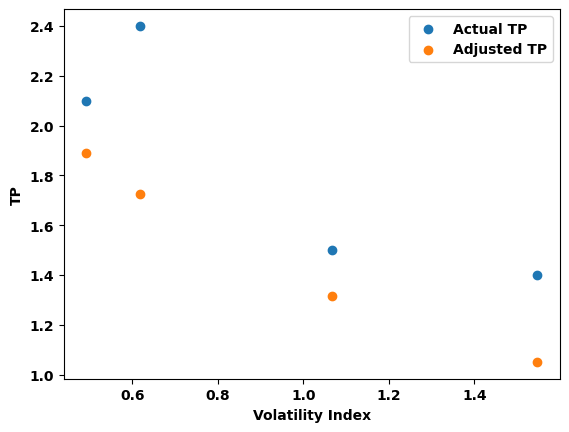

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["volatility_index"], df["tp_mean"], label="Actual TP")
plt.scatter(df["volatility_index"], df["TP_adjusted"], label="Adjusted TP")
plt.xlabel("Volatility Index")
plt.ylabel("TP")
plt.legend()
plt.show()